# <img style="float: left; padding-right: 20px; width: 200px" src="https://raw.githubusercontent.com/raxlab/imt2200-data/main/media/logo.jpg">  IMT 2200 - Introducción a Ciencia de Datos
**Pontificia Universidad Católica de Chile**<br>
**Instituto de Ingeniería Matemática y Computacional**<br>
**Semestre 2025-S2**<br>
**Profesor:** Rodrigo A. Carrasco <br>

# <h1><center>Tarea 03: Exploración de datos </center></h1>

**Fecha de Entrega:** 28 de octubre de 2025, a las 23:59.

**Fecha de publicación**: 14 de octubre de 2025.

**Formato de entrega:** Notebook ejecutado y comentado (`.ipynb`) en el módulo de Tarea 03 habilitado en Canvas.

## Instrucciones

- Esta Tarea debe desarrollarse de manera totalmente *individual*, de acuerdo a lo establecido en la sección de Integridad Académica en el programa del curso.
- La Tarea debe ser desarrollada en lenguaje de programación Python y la entrega en formato Jupyter Notebook.
- El desarrollo del Notebook debe ser claro y ordenado, incluyendo anotaciones (markdown) y comentarios que permitan seguir fácilmente el código y los pasos implementados a los correctores, y siguiendo buenas prácticas de programación. La presentación y claridad del notebook y código forman parte de la evaluación de la tarea.
- Notebook **autocontenible** que:
   - Ejecute sin errores todas las celdas.
  - Contenga tanto el código como los comentarios y explicaciones necesarias.
  - Incluya visualizaciones claras y correctamente etiquetadas.
- No se aceptarán notebooks con celdas rotas o que dependan de rutas externas no indicadas en la tarea.

- Deben hacer sus consultas y comentarios sobre la Tarea a través del canal de Tareas en el Foro del curso en Canvas.

---

## 1. Objetivos

- Aplicar los conceptos iniciales de manejo de datos y análisis exploratorio vistos en clases.
- Practicar la lectura, limpieza y manipulación de datos en Python.
- Desarrollar habilidades para visualizar y describir patrones y tendencias en conjuntos de datos reales.
- Fomentar la capacidad de comunicar resultados de forma clara y fundamentada.

### 1.1 Objetivo educacional

Esta Tarea tiene como objetivo que los estudiantes desarrollen la capacidad de manejar algunas de las librerías centrales para el desarrollo de Ciencia de Datos, con foco en la lectura y exploración de datos. 

Para los ejercicios a continuación, usted deberá leer, inspeccionar, manipular y graficar conjuntos de datos en distintos formatos, de manera de responder las preguntas de cada parte de la Tarea.

### 1.2 Pregunta de ciencia de datos

En esta tarea vamos a analizar la distribución de vulneribilidad escolar para distintos establecimientos educacionales en Chile, desde enseñanza parvularia hasta enseñanza media. Específicamente, queremos entender cómo se comporta un índice de vulnerabilidad en relación a variables como ruralidad, tipo de dependencia y comuna del establecimiento.

---

## 2. Datos

En este estudio, trabajaremos con los resultados publicados anualmente sobre por la JUNAEB
sobre vulnerabilidad de establecimientos educacionales en todo el territorio nacional. Estos resultados están disponibles en la siguiente página web:

* Índices de Vulnerabilidad (JUNAEB): https://www.junaeb.cl/medicion-la-vulnerabilidad-ivm/

Adicionalmente, para visualizar las variables, utilizaremos los mapas vectoriales que disponibiliza la Biblioteca del Congreso Nacional (BCN):

* Mapoteca BCN: https://www.bcn.cl/siit/mapas_vectoriales/index_html

### 2.1 Descarga de datos y conceptos generales (1 punto)

Acceda a los links entregados y descargue el set de datos del **Índice de Vulnerabilidad Multidimensional de Establecimientos Educacionales** para el año 2025. Este debería ser un documento XLSX con múltiples pestañas, incluyendo entre estas un índice que describe las columnas presentes en la base de datos.
Descargue además los archivos correspondientes a la **División comunal: polígonos de las comunas de Chile**. Este se descarga en formato `.zip` y contiene archivos shapefile para visualizar las comunas del país.

Investigue sobre este índice y responda de manera concisa: 
* ¿En qué consiste el IVM? ¿Qué rango de valores toma y qué significan? 
* ¿Cómo se obtiene el IVM de un establecimiento educacional?



### Respuesta:

El IVM (Índice de Vulnerabilidad Multidimensional) es una medida que busca identificar el riesgo educativo de los estudiantes considerando múltiples dimensiones del entorno y características del estudiante, no solo factores socioeconómicos. Evalúa el nivel de vulnerabilidad de los estudiantes y, por extensión, de los establecimientos educativos. Todo acorde JUNAEB.

## 3. Lectura y limpieza de datos (1 punto)

### 3.1 Datos de establecimientos (0.5 puntos)
El archivo descargado contiene información sobre establecimientos de cuatro tipos: Parvularia, Primer Ciclo Básica, Segundo Ciclo Básica y Media.
Cargue los datos de los establecimientos en cuatro DataFrames distintos.

Revise cada uno de sus sets de datos y haga un proceso de limpieza si lo considera necesario (manejo de valores nulos, duplicados, inválidos, transformación de tipos de datos, etc). De haberlos, identifique qué atributos son categóricos y transforme los tipos de columna de acuerdo a su decisión, mostrando todos los posibles valores de cada categoría.

Justifique **todas** sus decisiones, **incluso** si decide no realizar una limpieza o transformación.

Finalmente, responda:

* a. ¿Cuántos establecimientos tiene cada set de datos?
* b. ¿Cuánto espacio en memoria ocupan en total los 4 datasets?
* c. ¿Cuántos estudiantes fueron evaluados en todo el país para cada nivel de enseñanza para el año 2025?


In [89]:
#Librerías
import pandas as pd
from os.path import join
import geopandas as gpd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from random import sample

In [21]:
#función para ver si el los Dataframes tienen filas nulas
def detectar_col_nulas(dataframes: dict):
    for nombre, df in dataframes.items():
        # Filas con al menos un NaN
        filas_con_nan = df[df.isna().any(axis=1)]
        cantidad = len(filas_con_nan)
        print(f"📊 {nombre} tiene {cantidad} fila(s) con NaN.")
        if cantidad > 0:
            print(filas_con_nan)
            print("-" * 60)

#función para determinar existencia de filas duplicadas
def detectar_duplicadas(dataframes: dict):
    for nombre, df in dataframes.items():
        #Buscamos las duplicadas
        filas_duplicadas = df[df.duplicated(keep=False)]
        cantidad = len(filas_duplicadas)
        print(f"📋 {nombre} tiene {cantidad} fila(s) duplicada(s).")
        if cantidad > 0:
            print(filas_duplicadas)
            print("-" * 60)

#función para calcular los establecimietos (3.1 A)
def contar_establecimientos(dataframes: dict, columna_ingresada="ID_RBD"):
    resultados = {}
    for nombre, df in dataframes.items():
        if columna_ingresada not in df.columns:
            print(f"⚠️ {nombre}: no existe la columna '{columna_ingresada}'.")
            continue
        n_estab = df[columna_ingresada].nunique() #contamos los valores únicos
        resultados[nombre] = n_estab
        print(f"🏫 {nombre.upper()}: {n_estab} establecimientos únicos.")
    return resultados

#funcion que se usará para calcular la RAM utilizada por los dataframes antes y después del EDA (3.1 B). 
def calcular_ram(dataframes):
    total_ram = 0
    for nombre, df in dataframes.items():
        memoria = df.memory_usage(deep=True).sum() #Revisa la 
        total_ram += memoria
        memoria_por_df = memoria / 1024**2
        print(f" - {nombre}: {memoria_por_df} MB ({round(memoria_por_df, 2)} MB)") #de bytes a MB hay que dividir dos veces por 1024
    print(f"💾 Memoria total usada por los dataframes: {total_ram / 1024**2} MB ({round(total_ram / 1024**2, 2)} MB)")
    return total_ram

#funcion que recibe un dataframe y filtra los datos por el año 
def contar_estudiantes(dataframes, anio=2025, col_anio="ANIO"):
    resultados = {}
    for nombre, df in dataframes.items():
        if col_anio in df.columns:
            df_filtrado = df[df[col_anio] == anio]
            n_estudiantes = len(df_filtrado)
        else:
            n_estudiantes = len(df)
        resultados[nombre] = n_estudiantes
        print(f"👩‍🎓 {nombre}: {n_estudiantes} estudiantes evaluados en {anio}.")
    return resultados

def sumar_evaluados(dataframes):

    resultados = {}
    total_general = 0
    
    print("="*63)
    print("\nTotal de estudiantes evaluados por nivel de enseñanza (2025):")
    
    for nombre, df in dataframes.items():
        n_estudiantes = df['N EVALUADO'].sum()
        resultados[nombre] = n_estudiantes
        #acumulo los nros de estudiantes
        total_general += n_estudiantes
        
        # Imprime el resultado para este nivel
        #El método :, pone separador de miles
        print(f" 👩‍🎓 {nombre.upper()}: {n_estudiantes:,} estudiantes")
    
    print("-"*63)
    print(f" 📊 Total general evaluados 2025: {total_general:,} estudiantes")
    print("="*63)
    
    return resultados



In [22]:
path= join('data', 'IVM_Establecimientos_2025-2.xlsx')

df_media = pd.read_excel(path ,sheet_name='Media')
df_parvulos = pd.read_excel(path, sheet_name='Parvularia')
df_primer_c = pd.read_excel(path, sheet_name='1º Ciclo Básico')
df_segundo_c = pd.read_excel(path, sheet_name='2º Ciclo Básico')

d_dataframes = {
    "df_parvulos": df_parvulos,
    "df_primer_c": df_primer_c,
    "df_segundo_c": df_segundo_c,
    "df_media": df_media,
}


In [114]:
#Muestro algunos elementos de un dataframe para ver lo que nos enconramos:
display(df_media.sample(10))


,ID_RBD,DV_RBD,DS_NOM_ESTABLE,DS_TIPO_DEPENDENCIA,DS_RURALIDAD,ID_REGION_ESTABLE,ID_PROVINCIA_ESTABLE,ID_COMUNA_ESTABLE,DS_COMUNA_ESTABLE,N EVALUADO,IVM Establecimiento,IVM Bajo,IVM Medio,IVM Alto,IVM Muy Alto
2542,32060,9,ESCUELA HOSPITALARIA CLÍNICA RED SALUD SANTIAGO,Particular Subvencionado,Urbano,13,131,13106,Estación Central,9,24.762803,3,2,1,3
2418,25961,6,COLEGIO PALMARES,Particular Subvencionado,Urbano,13,131,13125,Quilicura,497,19.862408,205,47,61,184
2342,25571,8,COLEGIO EL RACO,Particular Subvencionado,Urbano,13,132,13201,Puente Alto,326,22.044180,128,38,32,128
122,647,5,COLEGIO MANUEL MONTT,Particular Subvencionado,Urbano,4,41,4102,Coquimbo,157,21.178144,58,20,17,62
2094,22224,0,COLEGIO PROYECCION SIGLO XXI,Particular Subvencionado,Urbano,10,103,10301,Osorno,110,16.603075,75,10,12,13
52,283,6,LICEO TECNICO ANTOFAGASTA,Corporación Municipal,Urbano,2,21,2101,Antofagasta,1048,24.295007,401,73,70,504
1515,12336,6,LICEO BICENTENARIO TECNICO PROFESIONAL DE MINERIA,Municipal DAEM,Urbano,5,54,5402,Cabildo,487,19.307380,246,49,57,135
1527,12591,1,LICEO SAMCA ARUMANTI,Particular Subvencionado,Urbano,1,11,1101,Iquique,435,19.633325,235,35,32,133
128,668,8,ESCUELA EDMUNDO VIDAL CARDENAS,Municipal DAEM,Urbano,4,41,4106,Vicuña,105,18.194170,67,6,11,21
382,2339,6,ESCUELA MUNICIPAL ZUNIGA,Corporación Municipal,Rural,6,61,6117,San Vicente,127,20.865806,67,11,9,40


In [24]:
print(df_media.columns)

Index(['ID_RBD', 'DV_RBD', 'DS_NOM_ESTABLE', 'DS_TIPO_DEPENDENCIA',
       'DS_RURALIDAD', 'ID_REGION_ESTABLE', 'ID_PROVINCIA_ESTABLE',
       'ID_COMUNA_ESTABLE', 'DS_COMUNA_ESTABLE', 'N EVALUADO',
       'IVM Establecimiento', 'IVM Bajo', 'IVM Medio', 'IVM Alto',
       'IVM Muy Alto'],
      dtype='object')


#### Ahora que la carga de datos fue exitosa, procedemos a determinar eventuales limpiezas:

In [25]:
#display(df_media.isna().sum(), df_parvulos.isna().sum(), df_primer_ciclo.isna().sum(), df_seg_ciclo.isna().sum())
detectar_col_nulas(d_dataframes)
print("="*50)
detectar_duplicadas(d_dataframes)

📊 df_parvulos tiene 0 fila(s) con NaN.
📊 df_primer_c tiene 0 fila(s) con NaN.
📊 df_segundo_c tiene 0 fila(s) con NaN.
📊 df_media tiene 0 fila(s) con NaN.
📋 df_parvulos tiene 0 fila(s) duplicada(s).
📋 df_primer_c tiene 0 fila(s) duplicada(s).
📋 df_segundo_c tiene 0 fila(s) duplicada(s).
📋 df_media tiene 0 fila(s) duplicada(s).


Como no hay duplicadas ni NaN, las entradas de los dataframes están bastante limpias. Ahora veremos los tipos de datos que contienen:

In [26]:
for i, df in enumerate(d_dataframes.values(), start=1):
    if i == 1:
        nombre = "df_parvulos"
    elif i == 2:
        nombre = "df_primer_c"
    elif i == 3:
        nombre = "df_segundo_c"
    else:
        nombre = "df_media"
    print("="*50)
    print(f"\n 📫 Información de tipos de datos de {nombre.upper()} 📫")
    display(df.info())


 📫 Información de tipos de datos de DF_PARVULOS 📫
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6163 entries, 0 to 6162
Data columns (total 21 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   ID_RBD                    6163 non-null   int64  
 1   DV_RBD                    6163 non-null   int64  
 2   DS_NOM_ESTABLE            6163 non-null   object 
 3   DS_TIPO_DEPENDENCIA       6163 non-null   object 
 4   DS_RURALIDAD              6163 non-null   object 
 5   ID_REGION_ESTABLE         6163 non-null   int64  
 6   ID_PROVINCIA_ESTABLE      6163 non-null   int64  
 7   ID_COMUNA_ESTABLE         6163 non-null   int64  
 8   DS_COMUNA_ESTABLE         6163 non-null   object 
 9   N EVALUADO                6163 non-null   int64  
 10  IVM Establecimiento       6163 non-null   float64
 11  IVM Bajo                  6163 non-null   int64  
 12  IVM Medio                 6163 non-null   int64  
 13  IVM Alto    

None


 📫 Información de tipos de datos de DF_PRIMER_C 📫
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7082 entries, 0 to 7081
Data columns (total 23 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   ID_RBD                7082 non-null   int64  
 1   DV_RBD                7082 non-null   int64  
 2   DS_NOM_ESTABLE        7082 non-null   object 
 3   DS_TIPO_DEPENDENCIA   7082 non-null   object 
 4   DS_RURALIDAD          7082 non-null   object 
 5   ID_REGION_ESTABLE     7082 non-null   int64  
 6   ID_PROVINCIA_ESTABLE  7082 non-null   int64  
 7   ID_COMUNA_ESTABLE     7082 non-null   int64  
 8   DS_COMUNA_ESTABLE     7082 non-null   object 
 9   N EVALUADO            7082 non-null   int64  
 10  IVM Establecimiento   7082 non-null   float64
 11  IVM Bajo              7082 non-null   int64  
 12  IVM Medio             7082 non-null   int64  
 13  IVM Alto              7082 non-null   int64  
 14  IVM Muy Alto         

None


 📫 Información de tipos de datos de DF_SEGUNDO_C 📫
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5662 entries, 0 to 5661
Data columns (total 15 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   ID_RBD                5662 non-null   int64  
 1   DV_RBD                5662 non-null   int64  
 2   DS_NOM_ESTABLE        5662 non-null   object 
 3   DS_TIPO_DEPENDENCIA   5662 non-null   object 
 4   DS_RURALIDAD          5662 non-null   object 
 5   ID_REGION_ESTABLE     5662 non-null   int64  
 6   ID_PROVINCIA_ESTABLE  5662 non-null   int64  
 7   ID_COMUNA_ESTABLE     5662 non-null   int64  
 8   DS_COMUNA_ESTABLE     5662 non-null   object 
 9   N EVALUADO            5662 non-null   int64  
 10  IVM Establecimiento   5662 non-null   float64
 11  IVM Bajo              5662 non-null   int64  
 12  IVM Medio             5662 non-null   int64  
 13  IVM Alto              5662 non-null   int64  
 14  IVM Muy Alto        

None


 📫 Información de tipos de datos de DF_MEDIA 📫
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2618 entries, 0 to 2617
Data columns (total 15 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   ID_RBD                2618 non-null   int64  
 1   DV_RBD                2618 non-null   int64  
 2   DS_NOM_ESTABLE        2618 non-null   object 
 3   DS_TIPO_DEPENDENCIA   2618 non-null   object 
 4   DS_RURALIDAD          2618 non-null   object 
 5   ID_REGION_ESTABLE     2618 non-null   int64  
 6   ID_PROVINCIA_ESTABLE  2618 non-null   int64  
 7   ID_COMUNA_ESTABLE     2618 non-null   int64  
 8   DS_COMUNA_ESTABLE     2618 non-null   object 
 9   N EVALUADO            2618 non-null   int64  
 10  IVM Establecimiento   2618 non-null   float64
 11  IVM Bajo              2618 non-null   int64  
 12  IVM Medio             2618 non-null   int64  
 13  IVM Alto              2618 non-null   int64  
 14  IVM Muy Alto          26

None

Notar que con .info() ya se obtiene la memoria usada (aproximada) por cada Dataframe respectivo, podríamos sumar cada valor para obtener lo pedido en **3.1 B** sin ambargo, se emplea la funcion `calcular_ram` para exponer lo pedido de forma más amigable.

In [27]:
memoria_total = calcular_ram(d_dataframes)

 - df_parvulos: 2.4612369537353516 MB (2.46 MB)
 - df_primer_c: 2.919889450073242 MB (2.92 MB)
 - df_segundo_c: 2.000594139099121 MB (2.0 MB)
 - df_media: 0.9323234558105469 MB (0.93 MB)
💾 Memoria total usada por los dataframes: 8.314043998718262 MB (8.31 MB)


Ahora, si convertimos columnas a tipo `category`, obtendremos un menor uso de memoria.

In [28]:
columnas_category = ['DS_TIPO_DEPENDENCIA','DS_RURALIDAD', 'DS_COMUNA_ESTABLE']
for df in d_dataframes.values(): #itero sobre los dataframes y no los nombres (que son las keys del d_dataframes)
    df[columnas_category] = df[columnas_category].astype('category')

In [29]:
#ahora reviso nuevamente la RAM usada, respuesta final 3.1 B
memoria_total_final = calcular_ram(d_dataframes)

 - df_parvulos: 1.3403940200805664 MB (1.34 MB)
 - df_primer_c: 1.6214580535888672 MB (1.62 MB)
 - df_segundo_c: 0.9632654190063477 MB (0.96 MB)
 - df_media: 0.46953392028808594 MB (0.47 MB)
💾 Memoria total usada por los dataframes: 4.394651412963867 MB (4.39 MB)


Notemos como bajó considerablemente el uso de memoria por los dataframes, esto es gracias a que pandas guarda los **valores únicos** dentro de las columnas y luego se refiere a ellos como ints, que son más ligeros de almacenar.

In [30]:
#respuesta 3.1 A
print(f"Respuesta 3.1 A\n{"="*46}")
total_establecimeintos = contar_establecimientos(d_dataframes, "ID_RBD")
display(total_establecimeintos)
print("="*46)

Respuesta 3.1 A
🏫 DF_PARVULOS: 6163 establecimientos únicos.
🏫 DF_PRIMER_C: 7082 establecimientos únicos.
🏫 DF_SEGUNDO_C: 5662 establecimientos únicos.
🏫 DF_MEDIA: 2618 establecimientos únicos.


{'df_parvulos': 6163,
 'df_primer_c': 7082,
 'df_segundo_c': 5662,
 'df_media': 2618}

Notar que los establecimientos únicos coinciden con el **número de entradas de cada dataframe**, esto respalda que nuestra funcion `detectar_duplicadas` haya retornado 0 filas repetidas dentro de los dataframes.

> - **Importante**
    Para la respuesta a la pregunta 3.1 A (*¿Cuántos establecimientos tiene cada set de datos?*), se utilizó `ID_RBD`, el cual corresponde al **Rol Base de Datos**. Convenientemente, en el proyecto semestral, con mi grupo nos habíamos topado con este identificador antes, lo que hizo intuitivo el razonamiento para usar este dato como identificador de los establecimientos.


In [31]:
#¿Cuántos estudiantes fueron evaluados en todo el país para cada nivel de enseñanza para el año 2025?
estudiantes_por_nivel = sumar_evaluados(d_dataframes)


Total de estudiantes evaluados por nivel de enseñanza (2025):
 👩‍🎓 DF_PARVULOS: 255,506 estudiantes
 👩‍🎓 DF_PRIMER_C: 882,881 estudiantes
 👩‍🎓 DF_SEGUNDO_C: 484,540 estudiantes
 👩‍🎓 DF_MEDIA: 901,899 estudiantes
---------------------------------------------------------------
 📊 Total general evaluados 2025: 2,524,826 estudiantes


### 3.2 Datos geográficos (0.5 puntos)

Cargue en un GeoDataFrame de GeoPandas la información de los polígonos de cada comuna del país.

Como realizamos en la Tarea pasada, puede transformar el Coordinate Reference System (CRS) a EPSG 4326, para tener la información de los puntos de los polígonos con latitud y longitud.

In [32]:
# Respuesta
path = join('data', 'Comunas.zip')

gdf_comunas =gpd.read_file(path)
print(gdf_comunas.crs)

EPSG:3857


In [33]:
#Como se hizo en la T2, cambiamos el CRS
gdf_comunas = gdf_comunas.to_crs("EPSG:4326")
print(gdf_comunas.crs)
gdf_comunas

EPSG:4326


,objectid,shape_leng,dis_elec,cir_sena,cod_comuna,codregion,st_area_sh,st_length_,Region,Comuna,Provincia,geometry
0,48,170038.624165,16,8,6204,6,9.685774e+08,206184.271675,Región del Libertador Bernardo O'Higgins,Marchigüe,Cardenal Caro,"POLYGON ((-71.80071 -34.20728, -71.79992 -34.2..."
1,29,125730.104795,15,8,6102,6,4.157446e+08,151911.576827,Región del Libertador Bernardo O'Higgins,Codegua,Cachapoal,"POLYGON ((-70.35293 -33.95263, -70.35243 -33.9..."
2,30,63026.084422,15,8,6103,6,1.448565e+08,76355.326122,Región del Libertador Bernardo O'Higgins,Coinco,Cachapoal,"POLYGON ((-70.90058 -34.23703, -70.90063 -34.2..."
3,31,89840.903562,15,8,6104,6,3.256572e+08,108874.623150,Región del Libertador Bernardo O'Higgins,Coltauco,Cachapoal,"POLYGON ((-71.02492 -34.17053, -71.0232 -34.17..."
4,78,122626.493264,23,11,9121,9,6.990727e+08,156680.410681,Región de La Araucanía,Cholchol,Cautín,"POLYGON ((-72.95898 -38.46877, -72.95797 -38.4..."
...,...,...,...,...,...,...,...,...,...,...,...,...
341,255,130240.555805,19,10,16305,16,8.751006e+08,160459.137929,Región de Ñuble,San Nicolás,Punilla,"POLYGON ((-72.24207 -36.35227, -72.24014 -36.3..."
342,253,311061.932415,19,10,16304,16,2.393007e+09,388109.613857,Región de Ñuble,San Fabián,Punilla,"POLYGON ((-71.24834 -36.45596, -71.24827 -36.4..."
343,245,159257.906431,19,10,16303,16,7.638173e+08,195593.933727,Región de Ñuble,Ñiquén,Punilla,"POLYGON ((-72.09907 -36.13712, -72.09819 -36.1..."
344,243,157467.049667,19,10,16104,16,1.044405e+09,196962.664313,Región de Ñuble,El Carmen,Ñuble,"POLYGON ((-71.74229 -36.82882, -71.74224 -36.8..."


## 4. Análisis descriptivo (1.5 puntos)

En esta sección haremos una exploración preliminar de los 4 sets de datos cargados. Para cada una de las siguientes preguntas, sustente su respuesta con al menos un gráfico y su análisis respectivo.

**Recomendación:** puede utilizar el método `subplots()` de `matplotlib.pyplot` para facilitar la visualización de múltiples gráficos a la vez.

### 4.1 Ruralidad (0.8 pts)
* a. ¿Cuál es la cantidad de establecimientos rurales vs urbanos según nivel de enseñanza?
* b. ¿Cómo se distribuye el IVM según nivel de enseñanza y ruralidad?


In [34]:
print(df_segundo_c.columns)

Index(['ID_RBD', 'DV_RBD', 'DS_NOM_ESTABLE', 'DS_TIPO_DEPENDENCIA',
       'DS_RURALIDAD', 'ID_REGION_ESTABLE', 'ID_PROVINCIA_ESTABLE',
       'ID_COMUNA_ESTABLE', 'DS_COMUNA_ESTABLE', 'N EVALUADO',
       'IVM Establecimiento', 'IVM Bajo', 'IVM Medio', 'IVM Alto',
       'IVM Muy Alto'],
      dtype='object')


In [ ]:
#Para responder estas preguntas, podemos unificar los dataframes pero solo con las columnas de interés.

df_p = df_parvulos[['DS_RURALIDAD', 'IVM Establecimiento']].copy()
df_p['Nivel'] = 'Parvularia'

df_c1 = df_primer_c[['DS_RURALIDAD', 'IVM Establecimiento']].copy()
df_c1['Nivel'] = '1º Ciclo Básico'

df_c2 = df_segundo_c[['DS_RURALIDAD', 'IVM Establecimiento']].copy()
df_c2['Nivel'] = '2º Ciclo Básico'

df_m = df_media[['DS_RURALIDAD', 'IVM Establecimiento']].copy()
df_m['Nivel'] = 'Media'

#concateo en solo uh dataframe
df_ruralidad_unificado = pd.concat([df_p, df_c1, df_c2, df_m])

# Aseguramos las columnas como category
df_ruralidad_unificado['DS_RURALIDAD'] = df_ruralidad_unificado['DS_RURALIDAD'].astype('category')
df_ruralidad_unificado['Nivel'] = df_ruralidad_unificado['Nivel'].astype('category')



/var/folders/hf/z4nqpl692qq20c0yrl9q93r40000gn/T/ipykernel_54472/3283376677.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  conteo_ruralidad = df_ruralidad_unificado.groupby('Nivel')['DS_RURALIDAD'].value_counts()#.unstack()


Nivel            DS_RURALIDAD
1º Ciclo Básico  Urbano          4128
                 Rural           2954
2º Ciclo Básico  Urbano          4170
                 Rural           1492
Media            Urbano          2449
                 Rural            169
Parvularia       Urbano          4903
                 Rural           1260
Name: count, dtype: int64

/var/folders/hf/z4nqpl692qq20c0yrl9q93r40000gn/T/ipykernel_54472/3283376677.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  conteo_ruralidad = df_ruralidad_unificado.groupby('Nivel')['DS_RURALIDAD'].value_counts().unstack()


DS_RURALIDAD,Rural,Urbano
Nivel,,
1º Ciclo Básico,2954,4128
2º Ciclo Básico,1492,4170
Media,169,2449
Parvularia,1260,4903


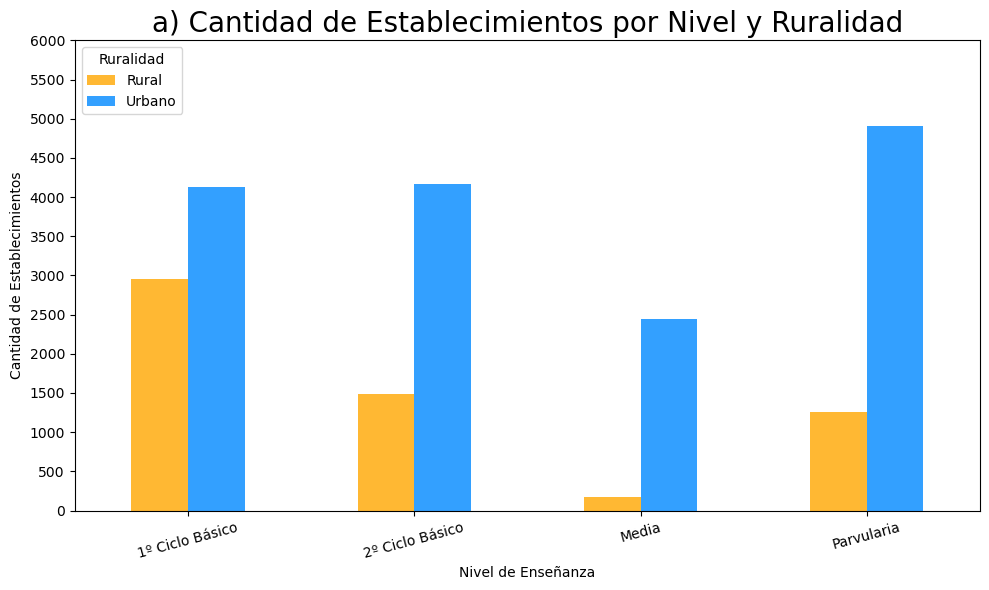

In [76]:
conteo_ruralidad = df_ruralidad_unificado.groupby('Nivel')['DS_RURALIDAD'].value_counts()#.unstack()
display(conteo_ruralidad) #asi queda el dataframe gracias a unstack (ver output)
conteo_ruralidad = df_ruralidad_unificado.groupby('Nivel')['DS_RURALIDAD'].value_counts().unstack()
display(conteo_ruralidad)

#Graficamos la tabla en una sola en vez de 4 gráficos, para no saturar la visual
ax_a = conteo_ruralidad.plot(
    kind='bar', 
    figsize=(10, 6),
    color=["#FFB833", '#33A0FF']
)


ax_a.set_xlabel('Nivel de Enseñanza')
ax_a.set_ylabel('Cantidad de Establecimientos')
ax_a.set_title('a) Cantidad de Establecimientos por Nivel y Ruralidad', fontsize=20)
ax_a.tick_params(axis='x', rotation=15)#roto las etiquetas para maypr legibilidad
ax_a.legend(title='Ruralidad', loc='upper left') #ubico la simbología en la esquina superior izq
ax_a.set_yticks(np.arange(0, 6001, 500)) #que el eje y llegue hasta 6000

plt.tight_layout()
plt.show()

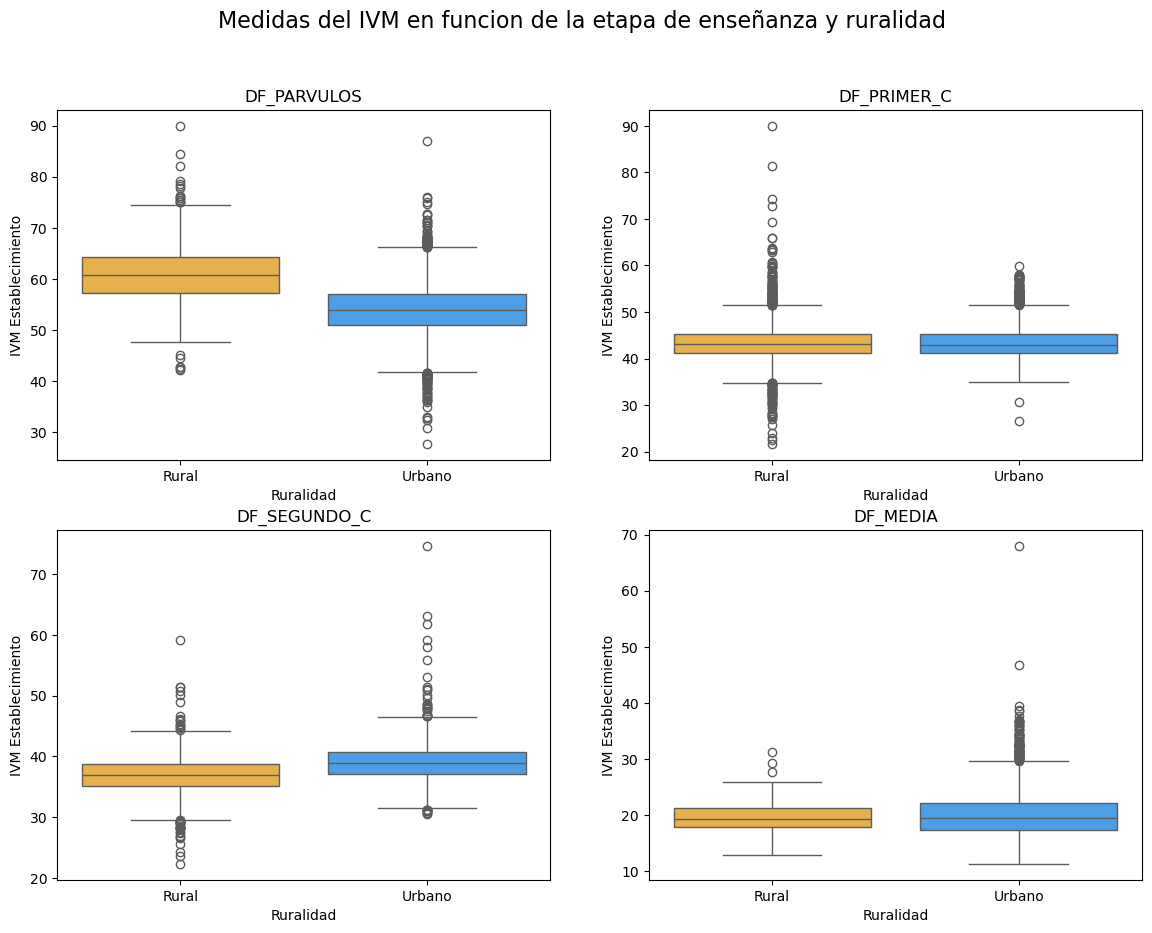

In [37]:
fig, axes = plt.subplots(2, 2, figsize=(14,10)) #creo una base para gráficar como una matriz 2x2
axes = axes.flatten()  # para iterar fácilmente

for i, nivel in enumerate(d_dataframes):
    df = d_dataframes[nivel] #selecciono el dataframe
    ax = axes[i] #con esto, asigno la ubicación de donde estará el gráfico

    df_temp = df[['DS_RURALIDAD', 'IVM Establecimiento']].copy()
    sns.boxplot(
        data=df_temp,
        x='DS_RURALIDAD',
        y='IVM Establecimiento',
        hue='DS_RURALIDAD',  # para evitar future warning
        palette={"Rural": "#FFB833", "Urbano": "#33A0FF"},
        ax=ax,
        legend=False
    )
    ax.set_title(f'{nivel.upper()}')
    fig.suptitle('Medidas del IVM en funcion de la etapa de enseñanza y ruralidad', fontsize=16)

    ax.set_xlabel('Ruralidad')
    ax.set_ylabel('IVM Establecimiento')




Respuesta y comentarios:

### 4.2 Tipo de establecimiento (0.7 pts)

* ¿Cómo es la distribución del IVM promedio de los establecimientos según tipo de dependencia y nivel de enseñanza? 

In [ ]:
promedios_por_nivel = {
    nombre: df.groupby('DS_TIPO_DEPENDENCIA', observed=True)['IVM Establecimiento'].mean()
    for nombre, df in d_dataframes.items() #for por comprensión
}
ivm_promedio_pivot = pd.DataFrame(promedios_por_nivel).T

#Le ponemos nombre al índice para que sea más claro
ivm_promedio_pivot.index.name = 'Nivel'

ivm_promedio_pivot

DS_TIPO_DEPENDENCIA,Administración Delegada (C. P. 3166),Corporación Municipal,Municipal DAEM,Particular Subvencionado,Servicio Local de Educación(SLE)
Nivel,,,,,
df_parvulos,NaN,54.412060,59.037537,53.565329,57.197915
df_primer_c,40.222215,45.013497,43.656486,42.723499,44.706152
df_segundo_c,40.522709,39.868568,37.870933,38.498390,38.605706
df_media,23.869148,23.679409,20.901203,19.159692,22.867277


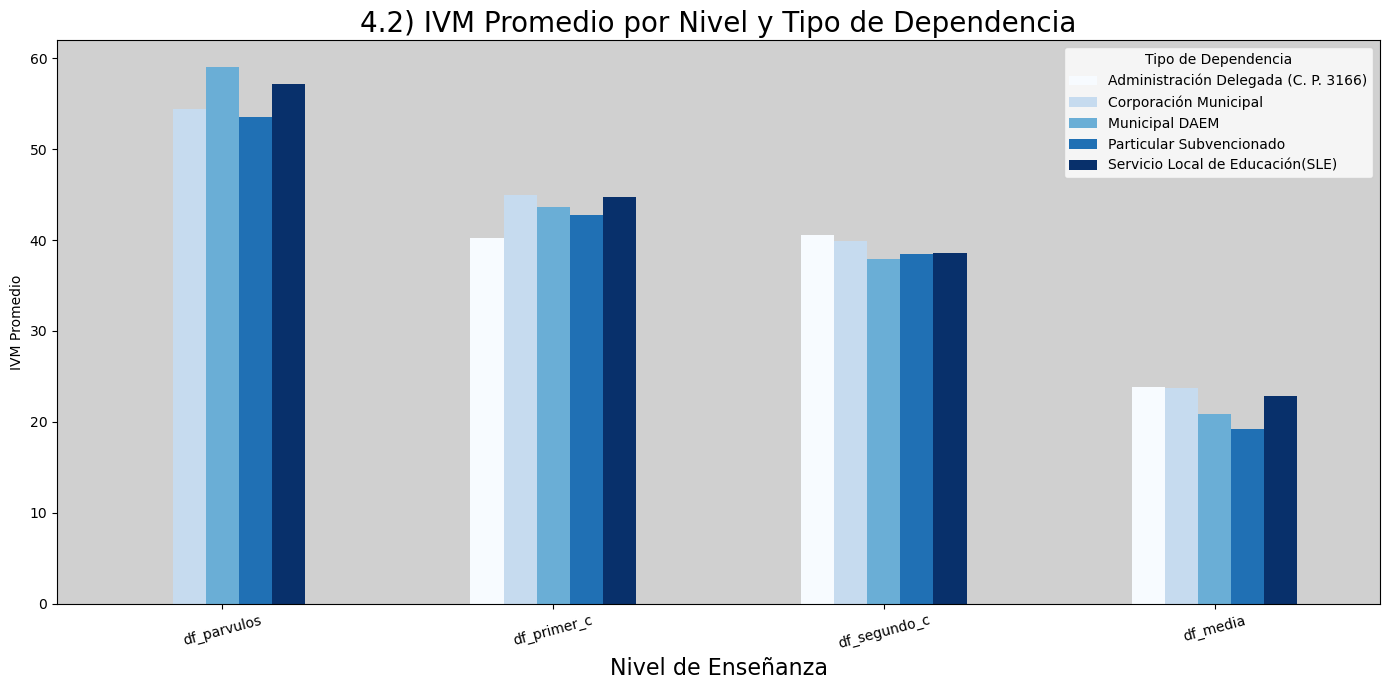

In [77]:
ax_barras = ivm_promedio_pivot.plot(
    kind='bar',
    figsize=(14, 7),
    colormap='Blues'
)
ax_barras.set_xlabel('Nivel de Enseñanza', fontsize=16)
ax_barras.set_ylabel('IVM Promedio')
ax_barras.set_title('4.2) IVM Promedio por Nivel y Tipo de Dependencia', fontsize=20)
ax_barras.set_facecolor("#D0D0D0") #para mejor lectura de las barras, mejora indudablemente la comprensión
ax_barras.tick_params(axis='x', rotation=15)
ax_barras.legend(title='Tipo de Dependencia', bbox_to_anchor=(1.0, 1.0))
plt.tight_layout()

Respuesta y comentarios:

### 4.3 Pregunta Bono: Dimensiones de vulnerabilidad (1 punto)

Para los niveles de enseñanza Parvularia y Básica Primer ciclo (1-4º), tenemos información sobre distintas dimensiones de que se utilizan para calcular el IVM, como condición socioeconómica familiar y comunal, salud, etc. 

* Para todo Chile, en promedio, ¿cuál es la dimensión con mayor puntaje de IVM para cada uno de estos dos niveles de enseñanza?

In [86]:
# Respuestas

Respuesta y comentarios:

## 5. Agrupación de bases de datos (2 puntos)

El objetivo de esta sección será agrupar los establecimientos según la comuna en la que se encuentran para obtener un resumen general sobre la vulnerabilidad escolar en cada una de ellas. Al finalizar esta sección, tendremos un nuevo DataFrame `agg_comunal` que contenga, al menos, la siguiente información:

* Comuna (nombre y ID)
* Región (ID)
* Cantidad de establecimientos rurales de la comuna
* Cantidad de establecimientos urbanos de la comuna
* Cantidad total de establecimientos de la comuna
* Porcentaje de establecimientos rurales
* IVM Promedio Parvularia de la comuna
* IVM Promedio Básica Primer Ciclo de la comuna
* IVM Promedio Básica Segundo Ciclo de la comuna
* IVM Promedio Media de la comuna
* Objeto geometry de GeoPandas correspondiente al polígono de la comuna respectiva

Armaremos este DataFrame paso a paso.

### 5.1 Cálculo de IVM promedio por comuna (0.8 pts)

Primero, para cada uno sus 4 DataFrames, calcule el promedio de la columna `IVM Establecimiento` según comuna. Almacene este valor en una nueva columna llamada `IVM Promedio {NIVEL DE ENSEÑANZA}` (por ejemplo, para enseñanza parvularia, cree la columna `IVM Promedio Parvularia`).

Junte los 4 resultados que obtuvo en un solo DataFrame `ivm_comunal` que contenga:
* Comuna (nombre y ID)
* Región (ID)
* IVM Promedio Parvularia de la comuna
* IVM Promedio Básica Primer Ciclo de la comuna
* IVM Promedio Básica Segundo Ciclo de la comuna
* IVM Promedio Media de la comuna

Ponga siempre atención al tamaño de sus DataFrames: como estamos agrupando comunalmente, estos siempre debiesen tener una cantidad de filas igual a las comunas de Chile.

In [126]:
mapeo_niveles = {
    "df_parvulos": "IVM Promedio Parvularia",
    "df_primer_c": "IVM Promedio Básica Primer Ciclo",
    "df_segundo_c": "IVM Promedio Básica Segundo Ciclo",
    "df_media": "IVM Promedio Media"
}

columnas_clave = ['ID_COMUNA_ESTABLE', 'DS_COMUNA_ESTABLE', 'ID_REGION_ESTABLE']

#notar que es más probable que parvulos tenga covertura en todas las comunas del pais, por eso se usa como base
base_comunal = (
    d_dataframes['df_parvulos'][columnas_clave]
    .drop_duplicates(subset='ID_COMUNA_ESTABLE')
    .copy()
)

#calculamos los promedios y los unimos a la base
for nombre_df, df_actual in d_dataframes.items():
    nombre_columna = mapeo_niveles[nombre_df]
    #ivm comunal
    resumen_ivm = (
        df_actual.groupby('ID_COMUNA_ESTABLE', as_index=False)
        ['IVM Establecimiento']
        .mean()
        .rename(columns={'IVM Establecimiento': nombre_columna})
    )

    #unimos
    base_comunal = base_comunal.merge(resumen_ivm, on='ID_COMUNA_ESTABLE', how='outer')

# Ajuste final de nombres y orden de columnas
ivm_comunal = (base_comunal.rename(columns={
        'DS_COMUNA_ESTABLE': 'NOMBRE_COMUNA',
        'ID_COMUNA_ESTABLE': 'ID_COMUNA',
        'ID_REGION_ESTABLE': 'ID_REGION'})
        [['NOMBRE_COMUNA', 'ID_COMUNA', 'ID_REGION'] + list(mapeo_niveles.values())]
)
#hacemos un sample para mostrar variedad
display(ivm_comunal.sample(10))
print(f"Cantidad de entradas del dataframe de IVMs por comuna {len(ivm_comunal)} ✅")
print(f"Cantidad de entradas del geodataframe de comunas {len(gdf_comunas)} ✅")


,NOMBRE_COMUNA,ID_COMUNA,ID_REGION,IVM Promedio Parvularia,IVM Promedio Básica Primer Ciclo,IVM Promedio Básica Segundo Ciclo,IVM Promedio Media
337,Portezuelo,16205,16.0,63.366117,40.383804,35.485326,15.656070
128,Rauco,7305,7.0,60.468929,44.941836,36.852074,20.347575
34,Salamanca,4204,4.0,57.375597,41.403399,38.062368,17.602074
194,Cholchol,9121,9.0,66.139694,44.909401,37.591292,17.796872
151,Tomé,8111,8.0,56.060381,42.228981,35.148884,17.370618
86,Malloa,6109,6.0,60.570040,43.852147,37.564441,22.876966
21,Vallenar,3301,3.0,55.293955,42.124223,36.967938,18.402311
221,Queilén,10207,10.0,65.206954,44.655156,32.319461,17.690968
259,Conchalí,13104,13.0,52.049950,45.316112,41.148872,26.335642
53,Cabildo,5402,5.0,57.392043,41.087928,36.115120,17.017804


Cantidad de entradas del dataframe de IVMs por comuna 345 ✅
Cantidad de entradas del geodataframe de comunas 346 ✅


Como Chile tiene 346 comunas, verificamos cuál es la faltante:

In [119]:
#Debido a las complicaciones que presentó identificar la comuna faltante, se le preguntó a chat gpt con el prompt
"""
Ayudame con un metodo que una o combine los dos dataframes (gdf_comunas e ivm_comunal) y filtre las comunas que no intersectan entre los dataframes.
gdf_comunas usa la columna cod_comuna y ivm_comunal usa ID_COMUNA"
"""

merged_data = gdf_comunas.merge(
    ivm_comunal,
    left_on='cod_comuna',  # Columna de ID en el mapa
    right_on='ID_COMUNA', # Columna de ID en los datos
    how='outer',           # 'outer' = mantener TODAS las filas de AMBOS
    indicator=True         # ¡La magia! Crea una columna llamada '_merge'
)

# 2. Filtra el resultado para mostrar solo las filas
#    que estaban en el mapa ('left_only') pero NO en los datos.
area_faltante = merged_data[merged_data['_merge'] == 'left_only']

# 3. Muestra el resultado
print("Área que está en el mapa pero NO en los datos de IVM (método merge):")
area_faltante[['cod_comuna', 'Region', 'Comuna', 'Region']]

Área que está en el mapa pero NO en los datos de IVM (método merge):


,cod_comuna,Region,Comuna,Region
0,0,Zona sin demarcar,Zona sin demarcar,Zona sin demarcar


Gracias a esto, podemos determinar que la *"comuna*" faltante es una zona sin demarcar. Por lo que no debería afecta a nuestro análisis.

### 5.2 Establecimientos por comuna y ruralidad (0.8 pts)

Ahora contaremos la cantidad de establecimientos por comuna según ruralidad. Como buscamos la cantidad total de establecimientos, consideramos establecimientos de todos los niveles educacionales vistos. Para esto, combine los 4 DataFrames que cargó y genere un nuevo DataFrame `estab_comunal` que contenga:

* Comuna (ID)
* Cantidad de establecimientos rurales
* Cantidad de establecimientos urbanos
* Cantidad total de establecimientos
* Porcentaje de establecimientos rurales (Establecimientos rurales / Total establecimientos * 100)

Tenga en cuenta de que pueden aparecer establecimientos duplicados al combinar estos 4 DataFrames (por ejemplo, establecimientos que imparten múltiples niveles de enseñanza, desde 1º básico hasta 4º medio). Preocúpese de manejar estos casos antes de agrupar sus datos según ruralidad.

In [145]:
df_concat = pd.concat([
    df_parvulos[['ID_RBD', 'ID_COMUNA_ESTABLE', 'DS_RURALIDAD']],
    df_primer_c[['ID_RBD', 'ID_COMUNA_ESTABLE', 'DS_RURALIDAD']],
    df_segundo_c[['ID_RBD', 'ID_COMUNA_ESTABLE', 'DS_RURALIDAD']],
    df_media[['ID_RBD', 'ID_COMUNA_ESTABLE', 'DS_RURALIDAD']]
], ignore_index=True)

#eliminamos los rdb repetidos
df_concat = df_concat.drop_duplicates(subset='ID_RBD')

#cuento los establecimientos
conteo = df_concat.groupby(['ID_COMUNA_ESTABLE', 'DS_RURALIDAD'])['ID_RBD'].count().unstack(fill_value=0)

# Renombramos columnas
conteo = conteo.rename(columns={'Rural': 'Rurales', 'Urbano': 'Urbanos'})

#calculo del %
conteo['Total_Estab'] = conteo.sum(axis=1)
conteo['Porcentaje_Rurales'] = conteo['Rurales'] / conteo['Total_Estab'] * 100

# Reseteamos índice para tener ID_COMUNA como columna
estab_comunal = conteo.reset_index()

# Mostramos resultado
estab_comunal.sample(5)

/var/folders/hf/z4nqpl692qq20c0yrl9q93r40000gn/T/ipykernel_54472/2908083804.py:12: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  conteo = df_concat.groupby(['ID_COMUNA_ESTABLE', 'DS_RURALIDAD'])['ID_RBD'].count().unstack(fill_value=0)


DS_RURALIDAD,ID_COMUNA_ESTABLE,Rurales,Urbanos,Total_Estab,Porcentaje_Rurales
153,8201,5,11,16,31.250000
300,13503,5,13,18,27.777778
252,12302,1,0,1,100.000000
286,13131,0,35,35,0.000000
259,13104,0,46,46,0.000000


### 5.3 Unión de bases de datos y polígonos (0.4 pts)

Finalmente, vamos a generar el DataFrame `agg_comunal` con la información de los dos previos DataFrames creados.
Combine la información de las dos secciones anteriores para crear su base de datos unificada. Por último, agregue la columna `geometry` con la información geográfica de cada comuna.

In [148]:
#por limpiar posibles errores
columnas_drop = [
    'objectid',
    'shape_leng',
    'dis_elec',
    'cir_sena',
    'st_area_sh',
    'st_length_'
]

#renombro y uno
gdf_base = gdf_comunas.rename(columns={'cod_comuna': 'ID_COMUNA'})
agg_comunal = gdf_base.merge(ivm_comunal, on='ID_COMUNA', how='left')
agg_comunal = agg_comunal.merge(
    estab_comunal[['ID_COMUNA_ESTABLE', 'Rurales', 'Urbanos', 'Total_Estab', 'Porcentaje_Rurales']],
    left_on='ID_COMUNA',
    right_on='ID_COMUNA_ESTABLE',
    how='left'
)
#limpieza
agg_comunal = agg_comunal.drop(columns=['ID_COMUNA_ESTABLE'], errors='ignore')
for col in columnas_drop:
    if col in agg_comunal.columns:
        agg_comunal = agg_comunal.drop(columns=col)

# Convertimos a GeoDataFrame
import geopandas as gpd
agg_comunal = gpd.GeoDataFrame(agg_comunal, geometry='geometry', crs=gdf_comunas.crs)

# Mostramos resultado
display(agg_comunal.sample(5))


,ID_COMUNA,codregion,Region,Comuna,Provincia,geometry,NOMBRE_COMUNA,ID_REGION,IVM Promedio Parvularia,IVM Promedio Básica Primer Ciclo,IVM Promedio Básica Segundo Ciclo,IVM Promedio Media,Rurales,Urbanos,Total_Estab,Porcentaje_Rurales
159,13117,13,Región Metropolitana de Santiago,Lo Prado,Santiago,"POLYGON ((-70.70559 -33.45716, -70.70621 -33.4...",Lo Prado,13.0,52.224536,45.686530,40.651078,23.988728,0.0,25.0,25.0,0.000000
330,6304,6,Región del Libertador Bernardo O'Higgins,Lolol,Colchagua,"POLYGON ((-71.68005 -34.88211, -71.68033 -34.8...",Lolol,6.0,64.319859,44.621825,38.734772,16.407856,6.0,3.0,9.0,66.666667
98,8105,8,Región del Bío-Bío,Hualqui,Concepción,"POLYGON ((-72.92553 -36.89216, -72.92493 -36.8...",Hualqui,8.0,57.330799,42.822389,37.050266,18.473858,12.0,8.0,20.0,60.000000
311,14203,14,Región de Los Ríos,Lago Ranco,Ranco,"POLYGON ((-71.85169 -40.52575, -71.85259 -40.5...",Lago Ranco,14.0,66.067534,45.311712,34.734739,18.279927,18.0,2.0,20.0,90.000000
125,8314,8,Región del Bío-Bío,Alto Biobío,Bío-Bío,"POLYGON ((-71.32249 -37.5554, -71.32218 -37.55...",Alto Biobío,8.0,74.730570,42.929878,34.047618,19.714586,9.0,0.0,9.0,100.000000


## 6. Análisis de vulnerabilidad por comuna (1.5 puntos)

### 6.1 Mapa de calor (0.8 pts)

Genere mapas de calor de las comunas de Chile según el IVM promedio de los establecimientos educacionales. Realice esto para cada etapa de enseñanza (Parvularia, Básica 1, Básica 2 y Media). Analice y comente sus resultados:
* ¿Cómo se diferencia la vulnerabilidad en distintos sectores del país según nivel de enseñanza?

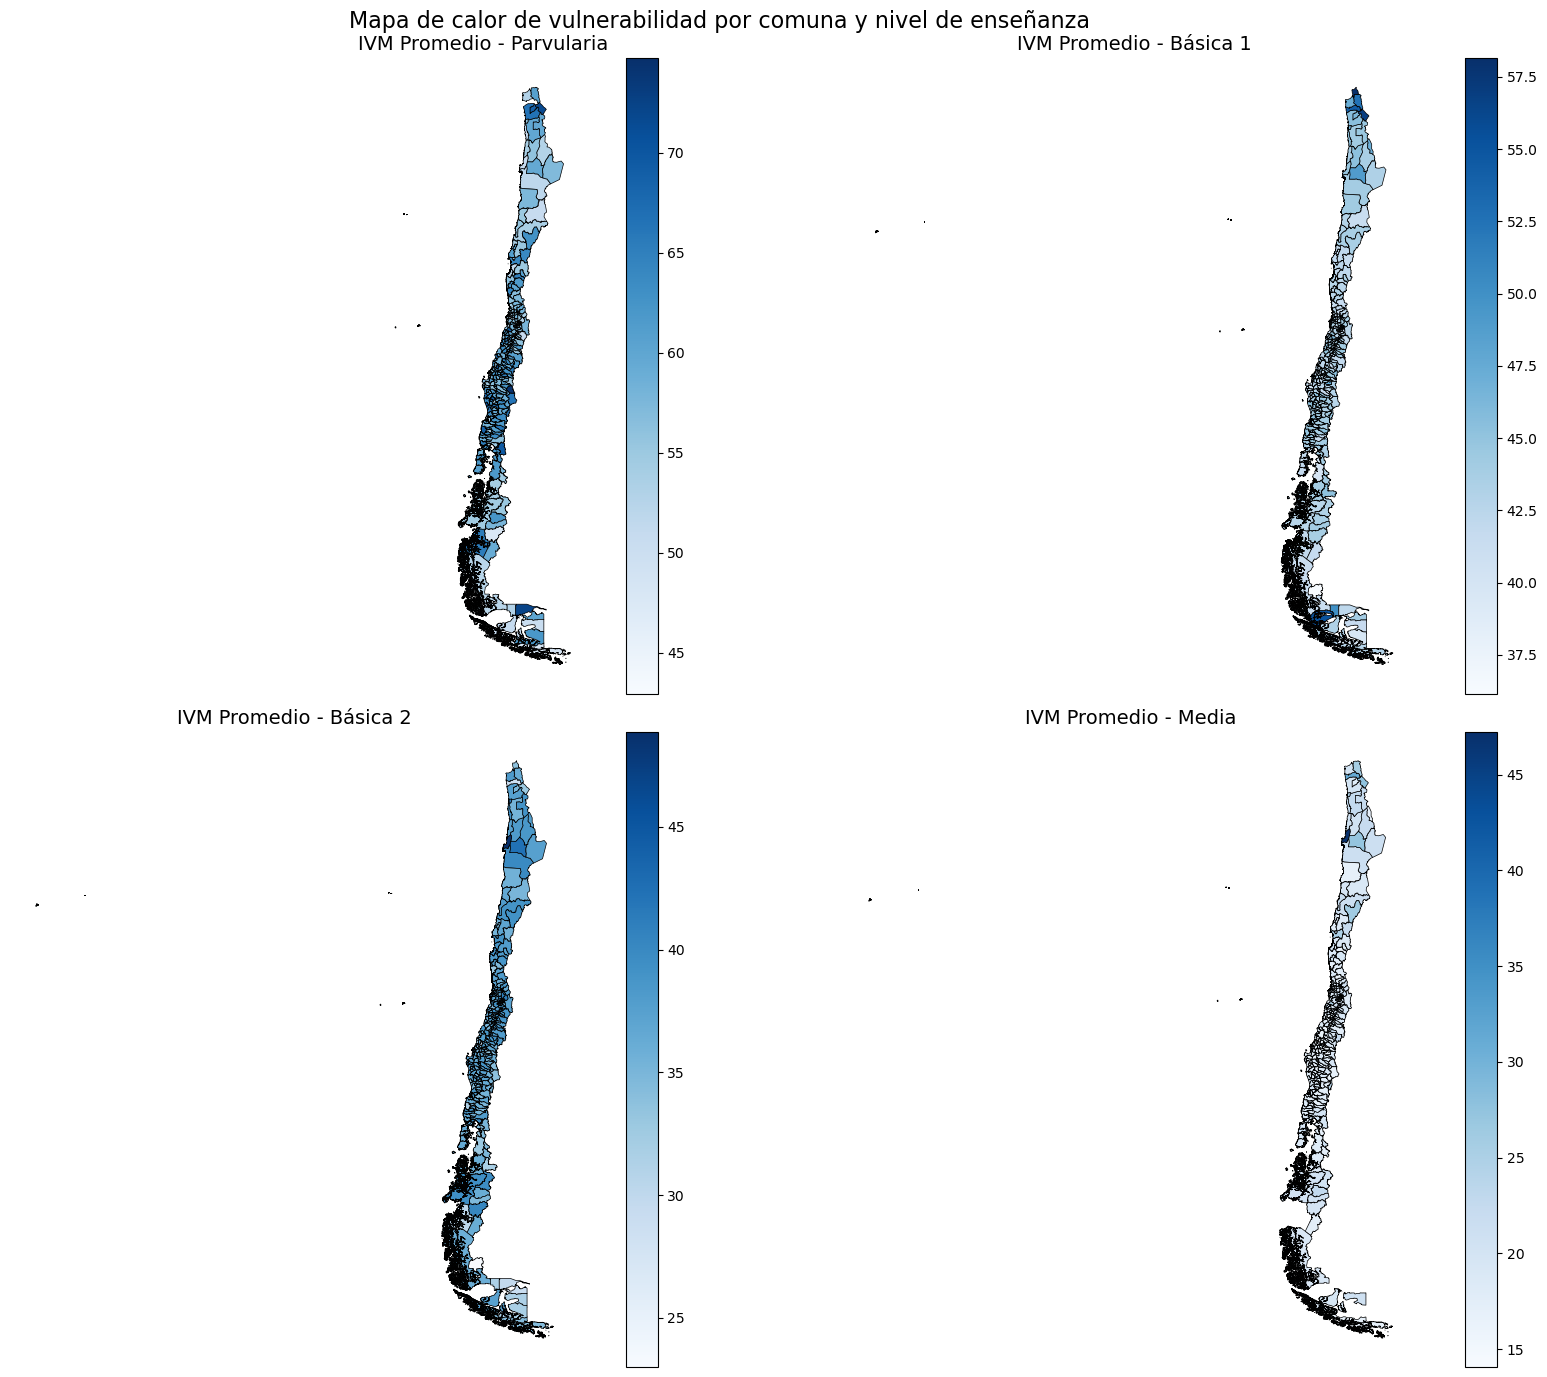

In [151]:

niveles_ivm = {
    'Parvularia': 'IVM Promedio Parvularia',
    'Básica 1': 'IVM Promedio Básica Primer Ciclo',
    'Básica 2': 'IVM Promedio Básica Segundo Ciclo',
    'Media': 'IVM Promedio Media'
}

# Creamos subplots (2x2)
fig, axes = plt.subplots(2, 2, figsize=(18, 14))
axes = axes.flatten()

for ax, (nivel, col_ivm) in zip(axes, niveles_ivm.items()):
    #Elementos del mapa de calor
    agg_comunal.plot(
        column=col_ivm,
        cmap='Blues',
        linewidth=0.5,
        edgecolor='black',
        legend=True,
        ax=ax
    )
    ax.set_title(f'IVM Promedio - {nivel}', fontsize=14)
    ax.axis('off')

plt.suptitle('Mapa de calor de vulnerabilidad por comuna y nivel de enseñanza', fontsize=16)
plt.tight_layout()
plt.show()


Comentarios y análisis:

### 6.2 Relación entre ruralidad comunal y vulnerabilidad (0.7 pts)

En la sección **5.2** definimos el **porcentaje de ruralidad** de cada comuna según la cantidad de establecimientos rurales en cada una. Analice y visualice los datos en `agg_comunal` para responder la siguiente pregunta:

* ¿Hay alguna correlación entre el IVM promedio y el porcentaje de ruralidad en las comunas de Chile?

In [44]:
# respuestas

## 7 Pregunta Bono (2 punto)

* Proponga una pregunta de análisis que le interese responder con los datos de cualquiera de las bases de datos leídas o generadas durante esta Tarea.
Respóndala de la misma forma que las preguntas anteriores, generando una o varias visualizaciones y analizando sus resultados. Justifique 

**Recomendación**: Trate de proponer una pregunta que justifique el uso de agregación de datos y visualización. En otras palabras, que
no pueda ser respondida directamente sin el uso de gráficos (por ejemplo, *"¿cuál es el establecimiento con mayor IVM?"* puede ser respondida con una búsqueda rápida en el DataFrame).

**Pregunta propuesta:**

In [45]:
# respuesta